# Modelo de regresión logística

# Programa o Script desarrollado por : Rolando Ortiz Herbas

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
#from mp.mpf import mp.mpf, getcontext
import mpmath as mp
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.decomposition import PCA


# Lectura del Dataset de entrenamiento : Clientes_Dos_Mil_TransEntrenamiento.csv

In [2]:
#mp.getcontext().prec = 30
ruta = "C:/Users/Roland/Documents/GitHub/Proyecto-I-y-II-MatUNADM/DatosClientes/variables_seleccionadas_entre.csv"

df = pd.read_csv(ruta , header=0)

In [3]:
mp.dps = 20
df.head()

,FechaUltimoPago,CostoAdmin,FechaAdjudicación,FechaInicioC,FechaProyectadaFin,MontoVencido,Ingresos,TotalMonto,SemanasAdjud,EdadActual,Mensualidad,Ocupacion,Y
0,20220106,27860,20180518,20161216,20211216,5626,27280,337617,74.0,46,5626,18,1
1,20220511,35932,20171020,20150320,20200320,5711,26926,342697,135.0,42,5711,107,1
2,20220222,28245,20170915,20161216,20211216,11274,29518,338249,39.0,23,5637,100,1
3,20220603,15889,20190920,20190315,20240315,8310,24596,249328,27.0,32,4155,77,1
4,20220601,22814,20181116,20171117,20221117,0,26367,274350,52.0,33,4572,97,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   FechaUltimoPago     1600 non-null   int64  
 1   CostoAdmin          1600 non-null   int64  
 2   FechaAdjudicación   1600 non-null   int64  
 3   FechaInicioC        1600 non-null   int64  
 4   FechaProyectadaFin  1600 non-null   int64  
 5   MontoVencido        1600 non-null   int64  
 6   Ingresos            1600 non-null   int64  
 7   TotalMonto          1600 non-null   int64  
 8   SemanasAdjud        1600 non-null   float64
 9   EdadActual          1600 non-null   int64  
 10  Mensualidad         1600 non-null   int64  
 11  Ocupacion           1600 non-null   int64  
 12  Y                   1600 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 162.6 KB


In [5]:
df = df.astype({col: 'float64' for col in df.select_dtypes(include='int64').columns})

# Verificar los tipos de datos
print(df.dtypes)

FechaUltimoPago       float64
CostoAdmin            float64
FechaAdjudicación     float64
FechaInicioC          float64
FechaProyectadaFin    float64
MontoVencido          float64
Ingresos              float64
TotalMonto            float64
SemanasAdjud          float64
EdadActual            float64
Mensualidad           float64
Ocupacion             float64
Y                     float64
dtype: object


# Inicializa coeficientes y lee las variables

In [6]:


B = pd.Series([0.1] * 30)
B0 = pd.Series([0.1] * 30)


X = np.array(df.iloc[:, :-1])

X1 = df.iloc[:, :-1]
#X = np.array(X1)
Y = np.array(df["Y"])


In [7]:
# 2 Estandarizar los datos
scaler = StandardScaler()
X = scaler.fit_transform(X)
X1 = scaler.fit_transform(X1)

In [8]:
alfa = 0.3
n = X.shape[1]
Nfilas = X.shape[0]


In [9]:

out = mp.mpf(0.0)
for i in range(n+1):
    
    if i == 0 :
        out = mp.mpf(B[0])
    else:
        out = mp.mpf(out) + mp.mpf(B[i]) * mp.mpf(X[0,i-1])   
pred = mp.mpf(0)        
pred = mp.mpf(1)/(mp.mpf(1) + mp.exp(-out)) 



In [10]:
mialfa = mp.mpf(alfa)
for i in range(n+1):
            
    if i == 0:
        B[i] = mp.mpf(B[i]) + mialfa * mp.mpf((Y[0]- pred)*1)
    else:
        B[i] = mp.mpf(B[i]) + mialfa * mp.mpf((Y[0]- pred)*X[0,i-1])
               
 

C:\Users\Roland\AppData\Local\Temp\ipykernel_3324\1406075874.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.233558685362097' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  B[i] = mp.mpf(B[i]) + mialfa * mp.mpf((Y[0]- pred)*1)


# Inicia el aprendizaje

In [11]:
for k in range(10):
    ###  aqui realiza 10 epocas
    for j in range(0,Nfilas):
        # el indice J recorre las filas del dataset
        out = mp.mpf(0.0)
        for i in range(n+1):
            # el indice i recorre las columnas del dataset
            if i == 0 :
                out = mp.mpf(B[0])
            else:
                out = mp.mpf(out) + mp.mpf(B[i]) * mp.mpf(X[j,i-1])
        pred =mp.mpf(0.0)
        pred = mp.mpf(1)/(mp.mpf(1) + mp.exp(-out)) 
        for i in range(n+1):
            
            if i == 0:
                B[0] = mp.mpf(B[0]) + mp.mpf(alfa) * (mp.mpf(Y[j]) - mp.mpf(pred)) * mp.mpf(1.0)
            else:
                B[i] = mp.mpf(B[i]) + mp.mpf(alfa) * (mp.mpf(Y[j]) - mp.mpf(pred)) * mp.mpf(X[j, i-1])
        
        
            

# Resultado de Los coeficientes B

In [13]:
for i in range(n+1):
   
    print("B[",i,"]",B[i])
    # print(f"{B[i]:15.7f}")
    #print("{:10.7f}".format(B[i]))
   #print("B[",i,"]",f"{B[i]:10.4f}")

B[ 0 ] 6.52325146336581
B[ 1 ] 0.201101590973356
B[ 2 ] 0.438064165199167
B[ 3 ] 0.874163003918478
B[ 4 ] 0.154081565629426
B[ 5 ] 0.154081565629426
B[ 6 ] -11.8996366213334
B[ 7 ] 0.820021894022994
B[ 8 ] 4.05804604270449
B[ 9 ] 0.455059988293643
B[ 10 ] -0.112771096803114
B[ 11 ] 1.76625982239134
B[ 12 ] 0.256761538047638


# Valida con el dataset de Prueba

# Lectura del dataset de prueba 

In [121]:
ruta_prueba = "C:/Users/Roland/Documents/GitHub/Proyecto-I-y-II-MatUNADM/DatosClientes/variables_seleccionadas_validacion.csv"
df_prueba = pd.read_csv(ruta_prueba , header=0)

In [122]:
X1_prueba = df_prueba.iloc[:, :-1]
X_prueba = np.array(X1_prueba)
Y_prueba = np.array(df_prueba["Y"])

In [123]:
X_prueba = scaler.fit_transform(X_prueba)
X1_prueba = scaler.fit_transform(X1_prueba)

In [124]:
print(X1_prueba)

[[-1.3312106  -0.69515833 -1.5032476  ... -1.28077518  0.03170108
  -0.44390895]
 [-1.33196812 -0.45964907 -1.51798036 ...  0.17953187 -0.79894477
  -0.70888528]
 [-0.74867261  0.35609391 -0.77797712 ... -1.19487476  0.22137611
  -1.44493063]
 ...
 [-1.32544174 -0.46938705 -1.5032476  ...  0.43723311 -0.92484975
  -0.70888528]
 [ 1.02184196  0.81063278  0.75512713 ...  1.81163974  0.22464637
   1.02818175]
 [-0.70287138  0.80658777 -0.75554144 ... -1.53847642 -0.58310766
  -1.29772156]]


In [125]:

np = X_prueba.shape[1]
Nfilasp = X_prueba.shape[0]
PYE = pd.Series([0.1] * Nfilasp)
YE = pd.Series([0.1] * Nfilasp)

# Evaluación de la función logística con los parametros de aprendizaje

In [126]:
for j in range(0,Nfilasp):
        out=mp.mpf(0.1)
        for i in range(np+1):
                if i == 0:
                        out = mp.mpf(out) + mp.mpf(B[0])*mp.mpf(1)
                       
                else:
                        out = mp.mpf(out) + mp.mpf(B[i]) * mp.mpf(X_prueba[j,i-1])
                       
        pred = mp.mpf(1)/(mp.mpf(1) + mp.exp(-out))
        
        PYE[j] = pred
        if float(pred) > float(0.5) :
                YE[j]=1
        else:
                YE[j]=0


C:\Users\Roland\AppData\Local\Temp\ipykernel_21024\1732694425.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.99997556211351774263892397405586639025806157226375' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  PYE[j] = pred


In [127]:
Aciertos = 0
Desaciertos = 0
for j in range(0,Nfilasp):
    if int(Y_prueba[j]) == int(YE[j]):
        Aciertos =Aciertos + 1
        #print(Y_prueba[j], YE[j],PYE[j])
    else:
        Desaciertos = Desaciertos + 1
        #print(Y_prueba[j], YE[j],PYE[j])
print("===================================================================")
print ("Aciertos : ", Aciertos,"Desaciertos" ,Desaciertos)
print ("Exactitud = Aciertos /( Aciertos + Desaciertos) = ", (Aciertos /(Aciertos + Desaciertos))*100,"%")  
print("===================================================================")  

Aciertos :  386 Desaciertos 14
Exactitud = Aciertos /( Aciertos + Desaciertos) =  96.5 %


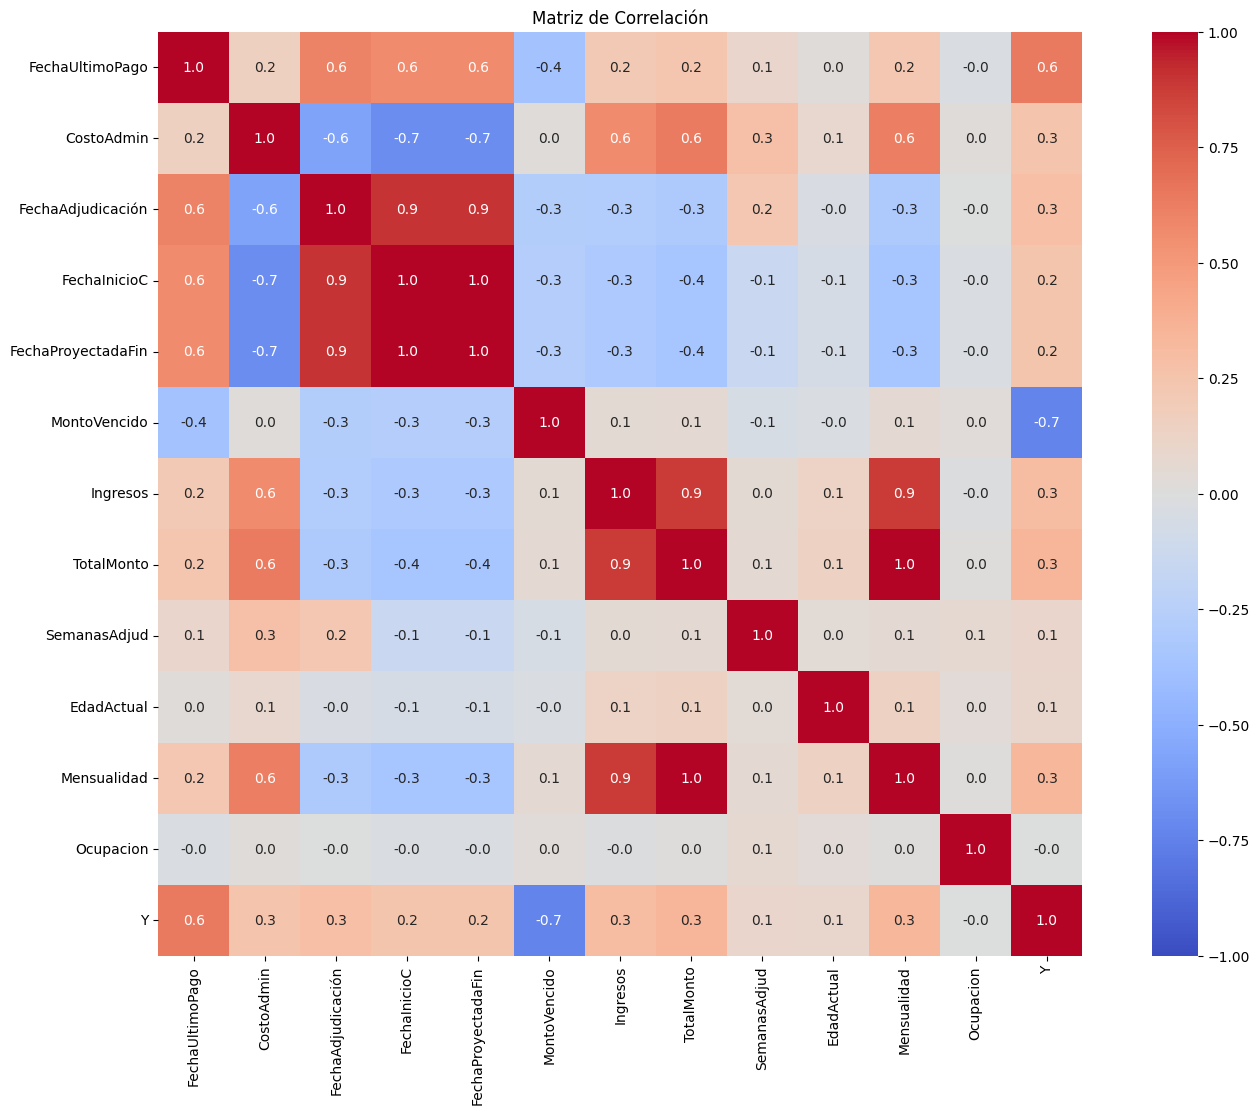

In [135]:
matriz_correlacion = df.corr()
# Crear un mapa de calor con valores numéricos en cada cuadro
plt.figure(figsize=(18, 12))  # Ajusta el tamaño de la figura según tus necesidades
sns.heatmap(matriz_correlacion, annot=True, fmt=".1f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title("Matriz de Correlación")
plt.show()

In [148]:
df = df.astype({col: 'float64' for col in df.select_dtypes(include='int64').columns})

In [149]:
df.head()

,FechaUltimoPago,CostoAdmin,FechaAdjudicación,FechaInicioC,FechaProyectadaFin,MontoVencido,Ingresos,TotalMonto,SemanasAdjud,EdadActual,Mensualidad,Ocupacion,Y
0,20220106.0,27860.0,20180518.0,20161216.0,20211216.0,5626.0,27280.0,337617.0,74.0,46.0,5626.0,18.0,1.0
1,20220511.0,35932.0,20171020.0,20150320.0,20200320.0,5711.0,26926.0,342697.0,135.0,42.0,5711.0,107.0,1.0
2,20220222.0,28245.0,20170915.0,20161216.0,20211216.0,11274.0,29518.0,338249.0,39.0,23.0,5637.0,100.0,1.0
3,20220603.0,15889.0,20190920.0,20190315.0,20240315.0,8310.0,24596.0,249328.0,27.0,32.0,4155.0,77.0,1.0
4,20220601.0,22814.0,20181116.0,20171117.0,20221117.0,0.0,26367.0,274350.0,52.0,33.0,4572.0,97.0,1.0


In [ ]:
df = df.drop(['Y'], axis=1) 

In [155]:
df.head()

,FechaUltimoPago,CostoAdmin,FechaAdjudicación,FechaInicioC,FechaProyectadaFin,MontoVencido,Ingresos,TotalMonto,SemanasAdjud,EdadActual,Mensualidad,Ocupacion
0,20220106.0,27860.0,20180518.0,20161216.0,20211216.0,5626.0,27280.0,337617.0,74.0,46.0,5626.0,18.0
1,20220511.0,35932.0,20171020.0,20150320.0,20200320.0,5711.0,26926.0,342697.0,135.0,42.0,5711.0,107.0
2,20220222.0,28245.0,20170915.0,20161216.0,20211216.0,11274.0,29518.0,338249.0,39.0,23.0,5637.0,100.0
3,20220603.0,15889.0,20190920.0,20190315.0,20240315.0,8310.0,24596.0,249328.0,27.0,32.0,4155.0,77.0
4,20220601.0,22814.0,20181116.0,20171117.0,20221117.0,0.0,26367.0,274350.0,52.0,33.0,4572.0,97.0


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   FechaUltimoPago     1600 non-null   float64
 1   CostoAdmin          1600 non-null   float64
 2   FechaAdjudicación   1600 non-null   float64
 3   FechaInicioC        1600 non-null   float64
 4   FechaProyectadaFin  1600 non-null   float64
 5   MontoVencido        1600 non-null   float64
 6   Ingresos            1600 non-null   float64
 7   TotalMonto          1600 non-null   float64
 8   SemanasAdjud        1600 non-null   float64
 9   EdadActual          1600 non-null   float64
 10  Mensualidad         1600 non-null   float64
 11  Ocupacion           1600 non-null   float64
dtypes: float64(12)
memory usage: 150.1 KB


In [159]:
# Calcular la media y la desviación estándar de cada columna
mean_A = np.mean(df, axis=0)  # Media por columna
std_A = np.std(df, axis=0)    # Desviación estándar por columna

In [160]:
A_standardized = (df - mean_A)
df_scaled = A_standardized

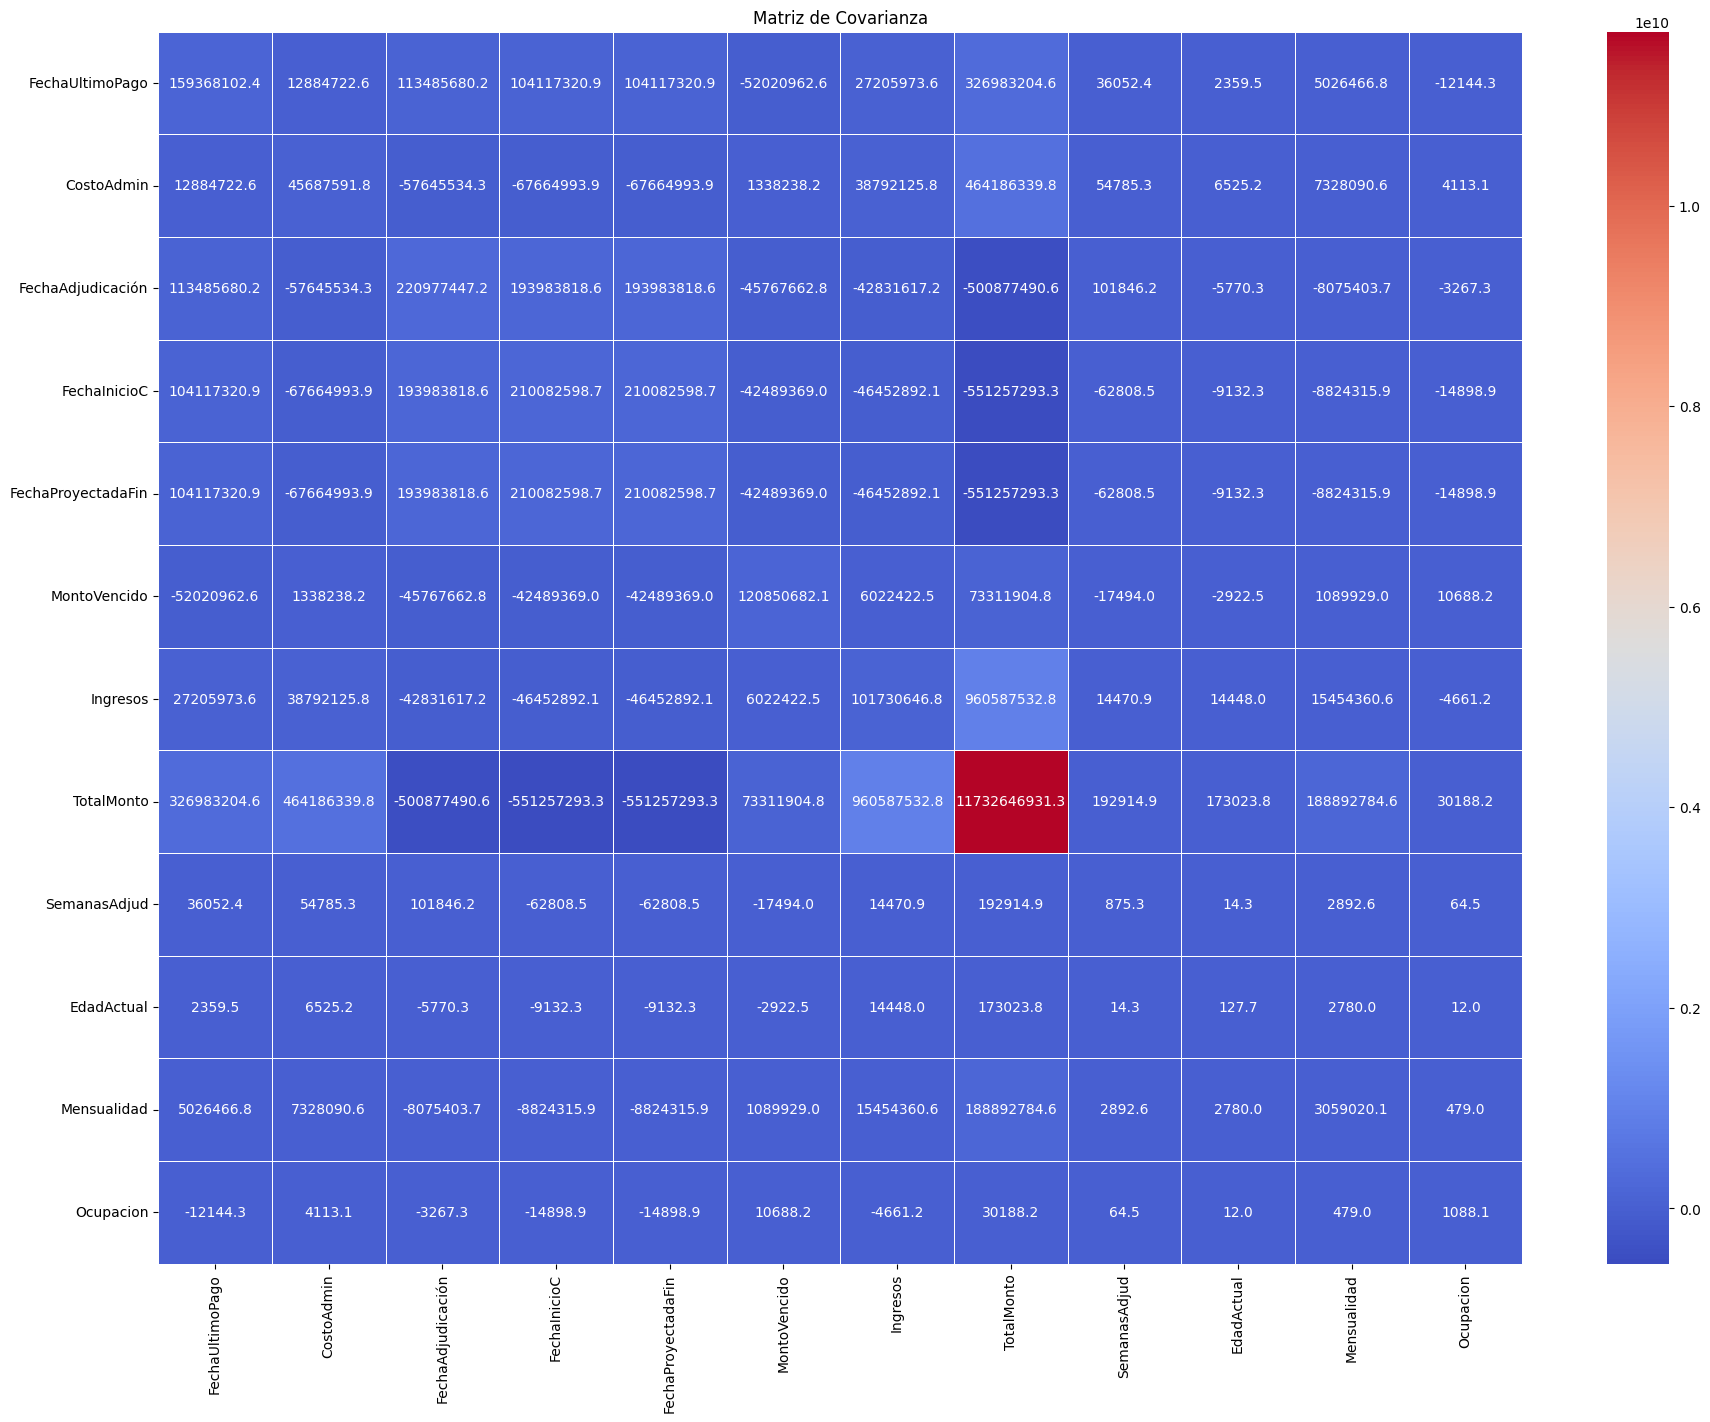

In [161]:
# Calcular matriz de covarianza
cov_matrix = df_scaled.cov()

# Graficar la matriz de covarianza como heatmap
plt.figure(figsize=(22, 16))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt=".1f", linewidths=0.5)

plt.title("Matriz de Covarianza")
plt.show()